# Анализ лояльности пользователей Яндекс Афиши

**Вводная часть.**

В этом проекте проводится анализ поведения пользователей сервиса Яндекс Афиша с целью выявить признаки, связанные с повторными покупками билетов. Результаты анализа могут быть использованы для более точного определения пользователей, которые с большей вероятностью вернутся к сервису, а также для формирования персонализированных предложений и более эффективного распределения маркетингового бюджета.

В рамках проекта используются данные о покупках пользователей Яндекс Афиши за период с июня по октябрь 2024 года. Для анализа рассматриваются сведения о заказах, пользователях, типах мероприятий, устройствах, регионах, количестве приобретённых билетов и выручке. Из исследования исключаются покупки билетов на фильмы, а также устройства, которые не относятся к мобильным и desktop-ным.

Работа состоит из нескольких последовательных этапов. Сначала проводится проверка и подготовка исходных данных. Затем выполняется исследовательский анализ поведения пользователей и сравнение характеристик тех, кто совершил только одну покупку, с пользователями, которые возвращались за повторными покупками.

Отдельно исследуется влияние характеристик первого заказа, количества билетов, выручки, типа мероприятия, устройства и временных факторов на вероятность повторной покупки. На заключительном этапе проводится оценка силы взаимосвязей между признаками и повторными покупками, после чего формулируются выводы.

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные.

Для выгрузки используйте запрос из SQL-запроса.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [21]:
# Загрузка библиотек
%pip install sqlalchemy 
#!pip install psycopg2 
%pip install psycopg2-binary
%pip install python-dotenv
%pip install pandas
%pip install matplotlib 
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# Импорт библиотек для работы с датафреймами и подключении к БД
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

try:
    import phik
except ImportError:
    %pip install phik
    import phik
    
import seaborn as sns

In [23]:
# Формирование строки коннекта
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_NAME = os.getenv('DB_NAME')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

In [24]:
# Извлечение запроса SQL
query = '''
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    tickets_count,
    (p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk::date)) AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases AS p
JOIN afisha.events AS e ON p.event_id = e.event_id
JOIN afisha.city AS c ON e.city_id = c.city_id
JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм'
ORDER BY p.user_id
''' 

In [25]:
# Результаты SQL-запроса
df = pd.read_sql_query(query, con=engine) 

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

**Начнем анализ данных**

In [26]:
# Размеры данных
df.shape

(290611, 15)

In [27]:
# Информация о данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [28]:
# Проверка пропусков
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

In [29]:
# Вид данных (первые 5 строк)
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


В результате выгрузки данных получено 290 611 строк и 15 именованных столбцов. Данные содержат информацию о пользователях, заказах, мероприятиях и локации.

Практически во всех столбцах не обнаружены пропуски, при этом столбец days_since_prev содержит 21 933 строк с незаполненными значениями. Такое наиболее вероятно случилось из-за того, что пользователь ранее не совершал заказ и соответственно данные о первом заказе отсутсвуют.

Типы данных в целом соответствуют содержанию столбцов. Но стоит обратить внимание на столбец days_since_prev, который по своей сути должен содержать целое число дней, но сейчас он представлен типом данных float64.

Также хочу отметить необхдимость оценки аномальных значений в столбце revenue. По 5 выведенным строкам можно заметить одно очень низкое значение выручки (revenue) для заказа с id=7292370, равное 8.49 rub. Оно выбивается из основной массы и может быть ошибочным.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [30]:
# Загрузим датасет с информацией о курсе тенге к рублю
tenge_df = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [31]:
# Первые строки
tenge_df.head(10)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [32]:
# Содержание датафрейма
tenge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 11.3 KB


In [33]:
# Стоит отметить, что данные в столбце data хранятся под типом object
# Приведем эти данные к типу даты (datetime64[ns])
tenge_df['data'] = pd.to_datetime(tenge_df['data'])

tenge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[us]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 11.3 KB


In [34]:
# Добавим к каждому заказу курс тенге по дате оформления заказа
df = df.merge(tenge_df[['data', 'curs']], left_on = 'order_dt', right_on = 'data', how = 'left')

df[['order_id', 'order_dt', 'currency_code', 'revenue', 'curs']].head()

,order_id,order_dt,currency_code,revenue,curs
0,4359165,2024-08-20,rub,1521.94,18.6972
1,7965605,2024-07-23,rub,289.45,18.3419
2,7292370,2024-10-06,rub,1258.57,19.6475
3,1139875,2024-07-13,rub,8.49,18.5010
4,972400,2024-10-04,rub,1390.41,19.6648


In [35]:
# Переменная преобразования в рубли
df['revenue_rub'] = df['revenue']

df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df.loc[df['currency_code'] == 'kzt', 'revenue'] 
    * df.loc[df['currency_code'] == 'kzt', 'curs'] / 100
)

df[['currency_code', 'revenue', 'curs', 'revenue_rub']].sort_values(by='currency_code', ascending = False).head()

,currency_code,revenue,curs,revenue_rub
0,rub,1521.94,18.6972,1521.94
192835,rub,538.26,19.0731,538.26
192841,rub,300.85,19.7319,300.85
192840,rub,585.37,20.2773,585.37
192839,rub,466.63,19.3262,466.63


In [36]:
df[['currency_code', 'revenue', 'curs', 'revenue_rub']].sort_values(by='currency_code', ascending = True).head()

,currency_code,revenue,curs,revenue_rub
83697,kzt,10338.19,19.8928,2056.555460
175997,kzt,414.43,19.0125,78.793504
175998,kzt,82.19,19.2591,15.829054
175999,kzt,1773.07,19.3741,343.516355
176000,kzt,410.58,19.6475,80.668706


In [37]:
# Проверим пропуски в созданном столбце
df['revenue_rub'].isna().sum()

np.int64(0)

По результатам пункта была приведена выручка к единой валюте - рублю. Для этого был создан новый столбец revenue_rub.
После преобразования пропущенных значений в новом столбце не было обнаружено.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

**Проверка пропусков в собранном датафрейме.**

In [38]:
# Проверяем на пропуски датафрейм
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
data                         0
curs                         0
revenue_rub                  0
dtype: int64

Пропуски наблюдаются только в столбце days_since_prev. Они относятся к 21 933 заказам и появляются у пользователей, для которых отсуствует предыдущая покупка. Таким образом, пропуск в данном случае вполне закономерное явление: он обозначает первый заказ пользователя. Заполнять пропуски не будем, чтобы не искажать информацию.

**Проверка типов данных.**

In [39]:
# Проверим типы данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


Все столбцы имеют верный формат данных. Для столбца days_since_prev предполагается заполнение ячеек целочисленными данными, однако на данный момент он имеет формат float64, что объясняется наличием NaN. Однако размерность можно оптимизировать, чтобы не занимать лишнюю память.

In [40]:
df[['tickets_count','order_id', 'event_id']].max()

tickets_count         57
order_id         8653108
event_id          592325
dtype: int64

In [41]:
df['tickets_count'] = df['tickets_count'].astype('int8')

In [42]:
df[['revenue', 'revenue_rub']].max()

revenue        81174.54
revenue_rub    81174.54
dtype: float64

In [43]:
df['revenue'] = df['revenue'].astype('float32')
df['revenue_rub'] = df['revenue_rub'].astype('float32')

In [44]:
df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')

In [45]:
# Итоговые типы данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


Таким образом, типы данных в столбцах полностью отражают их назначение и оптимизированы по параметру требуемой памяти.

**Проверка дубликатов.**

In [46]:
# Изначально проверим на полные дубликаты данные
print(df.duplicated().sum())

0


In [47]:
# Проверим уникальность id заказа, так как они не должны совпадать, нежели id user
print(df['order_id'].duplicated().sum())

0


In [48]:
# Проверим на всякий случай повторения в заказах при разных order_id
pot_duplicates = df.duplicated(
    subset=[
        'user_id',
        'order_dt',
        'order_ts',
        'event_id',
        'tickets_count',
        'revenue_rub',
        'device_type_canonical'
    ],
    keep=False
)
print('Потенциальных дубликатов:', pot_duplicates.sum())

Потенциальных дубликатов: 77


In [49]:
df.loc[pot_duplicates].sort_values(['user_id', 'order_dt', 'event_id']).head(77)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,curs,revenue_rub
11758,06eb7897f65b433,mobile,1123867,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0.0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,Светополянский округ,Глиноград,2024-08-13,18.8553,69.820000
11761,06eb7897f65b433,mobile,1123983,2024-08-13,2024-08-13 16:31:07,rub,69.820000,1,0.0,183706,69796237-909b-42a7-bfb5-c1b8574c4c76,театр,Билеты в руки,Светополянский округ,Глиноград,2024-08-13,18.8553,69.820000
26868,0dc525d7bacbb0d,desktop,1930705,2024-07-31,2024-07-31 13:26:11,rub,1556.050049,3,11.0,393430,b33d7a0b-a715-47e3-803e-02482884a73e,концерты,Лови билет!,Каменевский регион,Глиногорск,2024-07-31,18.2404,1556.050049
26870,0dc525d7bacbb0d,desktop,1930763,2024-07-31,2024-07-31 13:26:11,rub,1556.050049,3,0.0,393430,b33d7a0b-a715-47e3-803e-02482884a73e,концерты,Лови билет!,Каменевский регион,Глиногорск,2024-07-31,18.2404,1556.050049
53681,206ea45ec11d478,mobile,1935171,2024-10-29,2024-10-29 16:46:54,rub,601.690002,2,0.0,442183,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерты,Билеты в руки,Каменевский регион,Глиногорск,2024-10-29,20.0429,601.690002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285381,fd4d47438ebb946,desktop,8548070,2024-06-19,2024-06-19 15:40:50,rub,989.570007,3,0.0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,2024-06-19,19.2165,989.570007
285382,fd4d47438ebb946,desktop,8547809,2024-06-19,2024-06-19 15:40:56,rub,989.570007,3,0.0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,2024-06-19,19.2165,989.570007
285384,fd4d47438ebb946,desktop,8547867,2024-06-19,2024-06-19 15:40:56,rub,1319.430054,4,0.0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,2024-06-19,19.2165,1319.430054
285385,fd4d47438ebb946,desktop,8548041,2024-06-19,2024-06-19 15:40:50,rub,989.570007,3,0.0,489843,25a26bf3-cb70-4f37-a7f0-c97cc065d414,театр,Билеты без проблем,Каменевский регион,Глиногорск,2024-06-19,19.2165,989.570007


Таким образом, мы видим, что в данных наблюдаются одинаковые строки, но с разным order_id. Эту дублирующиеся данные и их необходимо удалить, чтобы не искажать результаты.

In [50]:
df = df.drop_duplicates(
    subset=[
        'user_id',
        'order_dt',
        'order_ts',
        'event_id',
        'tickets_count',
        'revenue_rub',
        'device_type_canonical'
    ],keep='first').copy()

In [51]:
df.shape

(290571, 18)

По итогам чистки дубликатов, было удалено 40 строк с одинаковыми данными, но неидентичным значением order_id.

**Проверка столбцов с категориями.**

In [52]:
df['device_type_canonical'].value_counts(dropna=False)

device_type_canonical
mobile     232460
desktop     58111
Name: count, dtype: int64

In [53]:
df['currency_code'].value_counts(dropna=False)

currency_code
rub    285503
kzt      5068
Name: count, dtype: int64

In [54]:
df['event_type_main'].value_counts(dropna=False)

event_type_main
концерты    115266
театр        67311
другое       65853
спорт        21906
стендап      13393
выставки      4853
ёлки          1989
Name: count, dtype: int64

In [55]:
df['service_name'].value_counts(dropna=False)

service_name
Билеты без проблем        63503
Лови билет!               41118
Билеты в руки             40336
Мой билет                 34835
Облачко                   26642
Лучшие билеты             17772
Весь в билетах            16848
Прачечная                 10273
Край билетов               6207
Тебе билет!                5227
Яблоко                     5039
Дом культуры               4502
За билетом!                2864
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2166
Быстробилет                2002
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Росбилет                    539
Шоу начинается!             499
Быстрый кассир              381
Радио ticket                376
Телебилет                   321
КарандашРУ                  133
Реестр                      125
Билет по телефону            85
Вперёд!                      80
Дырокол                      74
Кино билет                 

В категориальных столбцах пропущенных значений не обнаружено. Каждый из столбцов содержит уникальное наименование и дубликатов разного написания не наблюдается.

**Анализ численных данных.**

In [56]:
# Основные статистические показатели для выручки и количества билетов
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,290571.000000,290571.000000
mean,555.585938,2.754318
std,875.528748,1.170600
min,-90.760002,1.000000
25%,113.970001,2.000000
50%,351.140015,3.000000
75%,802.049988,4.000000
max,81174.539062,57.000000


Мы видим, что в столбце revenue_rub присутствуют отрицальные значения. Поэтому проверим их количество и удалим, так как эти данные могут означать возврат и не интересуют нас.

In [57]:
revenue_neg = (df['revenue_rub'] < 0).sum()
print('Количество заказов с отрицательной выручкой:', revenue_neg)
print('Доля заказов с отрицательной выручкой:', round(revenue_neg/len(df) * 100, 2), '%')

Количество заказов с отрицательной выручкой: 381
Доля заказов с отрицательной выручкой: 0.13 %


Отрицательная выручка обнаружена в 381 заказе, что составляет 0.13% данных. Доля таких наблюдений невелика и может быть исключена из общего набора.

In [58]:
df = df[df['revenue_rub'] >= 0].copy()

In [59]:
revenue_neg = (df['revenue_rub'] < 0).sum()
print(revenue_neg)

0


Были удалены все строки, значения выручки для которых имеет отрицательное значение.

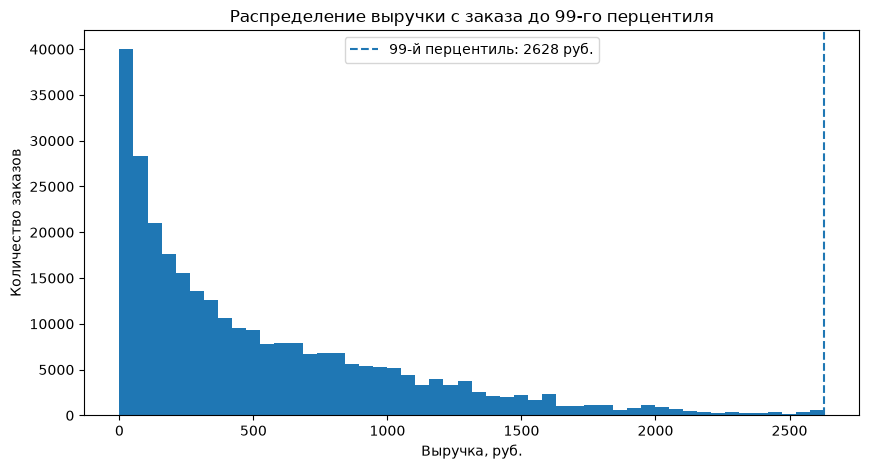

In [60]:
# Посмотрим наглядно на распределение выручки в пределах 99-го перцентиля
revenue_99 = df['revenue_rub'].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df['revenue_rub'] <= revenue_99, 'revenue_rub'],
    bins=50
)

plt.axvline(
    revenue_99,
    linestyle='--',
    label=f'99-й перцентиль: {revenue_99:.0f} руб.'
)

plt.title('Распределение выручки с заказа до 99-го перцентиля')
plt.xlabel('Выручка, руб.')
plt.ylabel('Количество заказов')
plt.legend()
plt.show()

C:\Users\sanya\AppData\Local\Temp\ipykernel_17312\2061795986.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


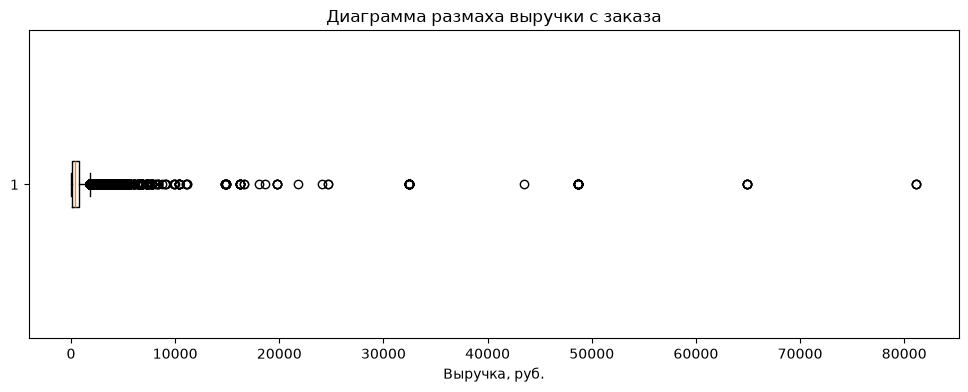

In [61]:
# Дополнительно построим диаграмму размаха выручки, чтобы оценить наличие выбросов
plt.figure(figsize=(12, 4))

plt.boxplot(
    df['revenue_rub'].dropna(),
    vert=False
)

plt.title('Диаграмма размаха выручки с заказа')
plt.xlabel('Выручка, руб.')
plt.show()

Теперь сделаем аналогично для количества билетов в заказе

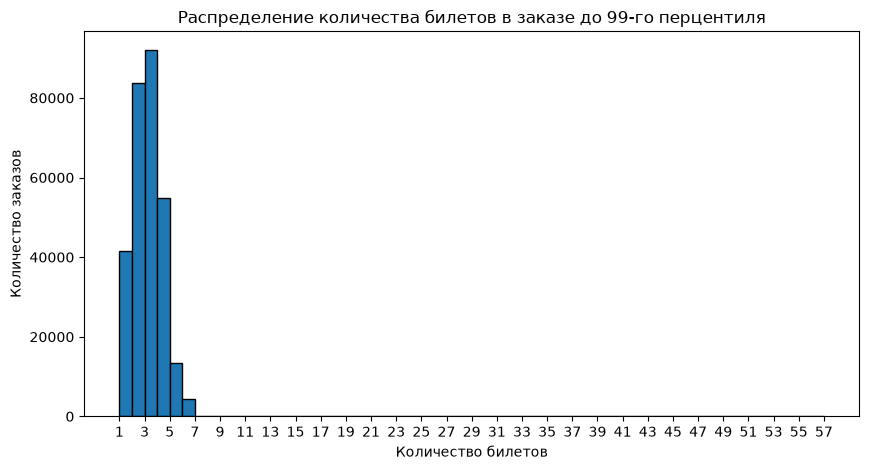

In [62]:
plt.figure(figsize=(10, 5))

plt.hist(
    df['tickets_count'],
    bins=range(1, df['tickets_count'].max() + 1),
    edgecolor='black'
)

plt.title('Распределение количества билетов в заказе до 99-го перцентиля')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')
plt.xticks(range(1, df['tickets_count'].max() + 1, 2))

plt.show()

C:\Users\sanya\AppData\Local\Temp\ipykernel_17312\2584516907.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['tickets_count'].dropna(), vert=False)


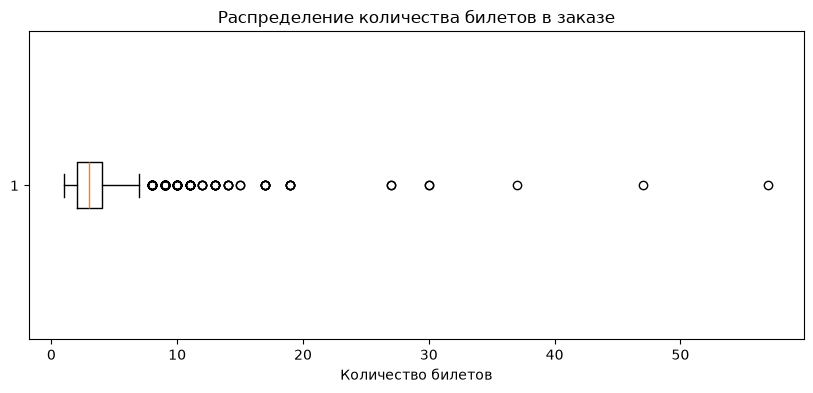

In [63]:
plt.figure(figsize=(10, 4))
plt.boxplot(df['tickets_count'].dropna(), vert=False)
plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.show()

После удаления отрицательных значений в столбце выручки. Проведем фильтрацию значений по 99-ому перцентилю, что позволит сохрнаить основную массу заказов, избежав при этом влияния небольшого колмчества аномально крупных значений на средние показатели.

Приступим к фильтрации выручки по процентилю 99-му:

In [64]:
print('Количество значений выше 99-го перцентиля:', (df['revenue_rub'] > revenue_99).sum())
print('Доля значений:', (df['revenue_rub'] > revenue_99).mean() * 100, '%')

Количество значений выше 99-го перцентиля: 2825
Доля значений: 0.9735001206106344 %


In [65]:
count_before = len(df)

df = df[df['revenue_rub']<=revenue_99].copy()

count_after = len(df)

print ('Строк до:', count_before)
print ('Строк после:', count_after)
print ('Строк удалено:', count_before - count_after)

Строк до: 290190
Строк после: 287365
Строк удалено: 2825


Распределение tickets_count показывает, что большинство заказов содержит небольшре количество билетов: медианное значение составляет 3 билета. При этом максимальное значение равно 57 билетам. Такие крупные заказы не обязательно являются ошибочными и могут соответствовать покупкам для нескольких человек.

In [66]:
# Проверка данных столбцов после фильтрации
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,287365.000000,287365.000000
mean,518.728271,2.741329
std,511.937012,1.163065
min,0.000000,1.000000
25%,112.639999,2.000000
50%,344.839996,3.000000
75%,788.900024,3.000000
max,2628.421631,57.000000


В ходе предобработки были проверены пропущенные значения в данных. Пропуски обнраружены только в столбце days_since_prev и не требуют заполнения, так как несут информацию о первом заказе клиента. Также выбраны наиболее правильные типы данных для столбцов. Где возможно изменена размерность.

Проверены категориальные признаки на наличие некорректных значений или пропусков. Ошибок в данных обнаружено не было.

Для столбцов revenue_rub и tickets_count проведены статистические показатели и построены графики распределения и диаграммы размаха. В столбце revenue_rub выявлены отрицательные значения (381). Такие значения могут быть связаны с возвратами и не интересуют нас при расчете выручки, поэтому они были исключены. После этого для обработки сильных выбросов применён 99-й перцентиль. В результате фильтрации удалено 2825 заказов, что составляет 0.97 % данных. Средняя выручка при этом снизилась с 555.59 руб до 518.73, а максимальное значение составляет 2628.42 руб.

Для tickets_count также выявлены достаточно высокое максимальное значение (57), но можно предполагать, что это групповое мероприятие, поэтому фильтрация этих данных не проводилась.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [67]:
# Отсортируем данные по пользователю и дате заказа
df_sorted = df.sort_values(['user_id', 'order_ts']).copy()

In [68]:
# Вытащим первый заказ
first_orders = df_sorted.drop_duplicates('user_id', keep='first')[
    [
        'user_id',
        'device_type_canonical',
        'region_name',
        'service_name',
        'event_type_main'
    ]
]
first_orders.head()

,user_id,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,mobile,Каменевский регион,Край билетов,театр
1,0005ca5e93f2cf4,mobile,Каменевский регион,Мой билет,выставки
3,000898990054619,mobile,Североярская область,Лови билет!,другое
6,00096d1f542ab2b,desktop,Каменевский регион,Край билетов,театр
7,000a55a418c128c,mobile,Поленовский край,Лучшие билеты,театр


In [69]:
# Создадим профиль пользователя
user_profile = df.groupby('user_id')['order_id'].nunique().reset_index()

# Количество заказов
user_profile.columns = ['user_id', 'total_orders']

# Дата первого заказа
user_profile['first_order_dt'] = df.groupby('user_id')['order_dt'].min().values

# Дата последнего заказа
user_profile['last_order_dt'] = df.groupby('user_id')['order_dt'].max().values

# Средняя выручка с заказа
user_profile['avg_revenue_rub'] = df.groupby('user_id')['revenue_rub'].mean().values

# Среднее количество билетов в заказе
user_profile['avg_tickets_count'] = df.groupby('user_id')['tickets_count'].mean().values

# Среднее время между заказами
user_profile['avg_days_between_orders'] = df.groupby('user_id')['days_since_prev'].mean().values

user_profile = user_profile.merge(first_orders, on='user_id', how='left')

In [70]:
user_profile.head()

,user_id,total_orders,first_order_dt,last_order_dt,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,device_type_canonical,region_name,service_name,event_type_main
0,0002849b70a3ce2,1,2024-08-20,2024-08-20,1521.939941,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр
1,0005ca5e93f2cf4,2,2024-07-23,2024-10-06,774.010010,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки
2,000898990054619,3,2024-07-13,2024-10-23,767.213379,2.666667,51.0,mobile,Североярская область,Лови билет!,другое
3,00096d1f542ab2b,1,2024-08-15,2024-08-15,917.830017,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр
4,000a55a418c128c,2,2024-09-29,2024-10-15,61.309998,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр


На основе количества заказов добавим два бинарных признака. is_two принимает значение 1 для пользователей, совершивших не менее двух заказов, а is_five - для пользователей с пятью и более заказами. 

Такие признаки позволят оценить степень вовлеченности пользователей в дальнейшем анализе.

In [71]:
# Добавим бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

In [72]:
# Проверим работу столбцов с бинарными признаками
user_profile[['user_id', 'total_orders', 'is_two', 'is_five']].head(10)

,user_id,total_orders,is_two,is_five
0,0002849b70a3ce2,1,0,0
1,0005ca5e93f2cf4,2,1,0
2,000898990054619,3,1,0
3,00096d1f542ab2b,1,0,0
4,000a55a418c128c,2,1,0
5,000cf0659a9f40f,13,1,1
6,00147c9209d45d3,2,1,0
7,0018ecd8a38a51b,1,0,0
8,00199a573901564,1,0,0
9,001e7037d013f0f,3,1,0


In [73]:
# Посмотрим на итоговый вид датафрейма
user_profile.head()

,user_id,total_orders,first_order_dt,last_order_dt,avg_revenue_rub,avg_tickets_count,avg_days_between_orders,device_type_canonical,region_name,service_name,event_type_main,is_two,is_five
0,0002849b70a3ce2,1,2024-08-20,2024-08-20,1521.939941,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0
1,0005ca5e93f2cf4,2,2024-07-23,2024-10-06,774.010010,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0
2,000898990054619,3,2024-07-13,2024-10-23,767.213379,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0
3,00096d1f542ab2b,1,2024-08-15,2024-08-15,917.830017,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0
4,000a55a418c128c,2,2024-09-29,2024-10-15,61.309998,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0


In [74]:
print('Количество пользователей:', user_profile['user_id'].nunique())

Количество пользователей: 21838


В результате сформирован профиль 21838 пользователей. Для каждого пользователя определены даты первого и последнего заказа, данные первого заказа, общее количество заказов, средняя выручка, среднее количество билетов и среднее время между заказами.
Дополнительно сформированы бинарные признаки is_two и is_five, которые позволяют выделить пользователей с повторными заказами и наиболее высокой частотой покупок. Полученный профиль будет использоваться при дальнейшем анализе.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [75]:
# Основные показатели
users_count = user_profile['user_id'].nunique()
print('Количество пользователей:', users_count)

print('Средняя выручка с заказа:', round(user_profile['avg_revenue_rub'].mean(), 2), 'руб.')

print('Доля пользователей с более 1 заказа:', round((user_profile['is_two'].sum() / users_count)  * 100, 2), '%')

print('Доля пользователей с более 4 заказов:', round((user_profile['is_five'].sum() / users_count) * 100, 2), '%')

Количество пользователей: 21838
Средняя выручка с заказа: 545.03 руб.
Доля пользователей с более 1 заказа: 61.7 %
Доля пользователей с более 4 заказов: 28.99 %


In [76]:
# Статистические показатели
user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe()

,total_orders,avg_tickets_count,avg_days_between_orders
count,21838.000000,21838.000000,13509.000000
mean,13.158943,2.744063,15.844014
std,121.564858,0.913068,22.293245
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.080000,20.428571
max,10168.000000,11.000000,148.000000


Можно наблюдать, что данные в avg_tickets_count не имеют ошибок. Значение 11 для максимального количества билетов в одном заказе выглядит достаточно приемлемым. 

То же самое касается и столбца avg_days_between_orders. Значение 0 говорит о том, что пользователь мог совершить два заказа в один день, что является вполне нормальным. А период в 148 дней означает низкую активность пользователя.

Однако стоит обратить внимание на столбец total_orders. Для него среднее значение наблюдается в районе 13 заказов. Однако максимальное значение кратно превышает данное значение и равняется 10168. Это вероятно ошибка в данных, которая может искажать данные для исследования. Поэтому рассмотрим подробно пользователей с большим количеством заказов.

In [77]:
# Посмотрим на пользователей с большим количеством заказов
user_profile[
    ['user_id', 'total_orders', 'avg_tickets_count', 'avg_days_between_orders']
].sort_values('total_orders', ascending=False).head(20)

,user_id,total_orders,avg_tickets_count,avg_days_between_orders
981,0beb8fc0c0a9ce1,10168,2.863297,0.014852
2054,18e9aead0a393e7,4346,2.789692,0.034983
11069,8187dac4be757a0,4014,2.748879,0.037628
5413,3ee7dc2e115847f,3785,2.764861,0.039641
10806,7eb4fc207ecc10f,3706,2.957906,0.040486
2330,1c2a2133e1df1b4,3502,2.670188,0.043416
6774,4ec8f6429431987,3375,2.725926,0.044458
14756,ad2dc32364ed948,3248,2.940271,0.046504
15492,b54dd0cd81121fc,3128,2.816496,0.048289
17621,cdbc02c6ad8087a,3031,2.765094,0.049835


Исходя из полученных данных, можно сделать вывод о том, что выбросы в столбце total_orders являются вполне закономерным явлением. Пользователи осуществляют покупки билетов достаточно часто и при этом за один заказ в среднем более 2. Это возможно, если данный пользователь является организатором мероприятий (посредником), который проводит групповые мероприятия или экскурсии.

In [78]:
# Посмотрим на пользователей с avg_days_between_orders=0
user_profile[
    ['user_id', 'total_orders', 'avg_tickets_count', 'avg_days_between_orders', 'first_order_dt', 'last_order_dt']
].sort_values('avg_days_between_orders', ascending=True).head(20)

,user_id,total_orders,avg_tickets_count,avg_days_between_orders,first_order_dt,last_order_dt
4866,38f2f84811d358d,2,3.000000,0.0,2024-08-29,2024-08-29
21764,ff3b99c9472a13d,3,2.000000,0.0,2024-10-12,2024-10-12
6,00147c9209d45d3,2,1.500000,0.0,2024-06-25,2024-06-25
10,0020c5654c92ec1,2,2.000000,0.0,2024-07-02,2024-07-02
66,00d6b4664563530,3,3.333333,0.0,2024-08-02,2024-08-02
72,00e62ce48c12cb4,2,3.500000,0.0,2024-09-19,2024-09-19
4692,36eb89e415c0857,4,2.250000,0.0,2024-10-31,2024-10-31
76,00eff51d57d00fb,2,4.500000,0.0,2024-09-30,2024-09-30
79,00f5131ed2d9533,6,2.166667,0.0,2024-09-12,2024-09-12
21741,fef4934157c82f1,2,3.000000,0.0,2024-07-30,2024-07-30


**Промежуточный вывод**

В выборке представлено 21838 пользователя. Средняя выручка с одного заказа составляет 545.03 руб. Доля пользователей, которые совершили 2 и более заказа, составляет 61.7%, а доля пользователей с 5 и более заказами - 29.0%. Полученного объёма данных вполне достаточно для дальнейшего исследовательского анализа.

Стоит отметить информацию по главным статистическим параметрам.
По показателю avg_tickets_count аномальных значений не обнаружено. Медианное значение составляет 2.74 билета за заказ, а максимальное - 11 билетов. Такое значение выглядит допустимым и не требует доп. фильтрации.

В показатели avg_days_between_orders также не обнаружено значений, которые кажутся ошибочными. Значение 0 означает, что пользователь мог совершить несколько заказов в один день, а максимальное значение 148 дней говорит о пользователях с низкой активностью.

При этом в столбце total_orders наблюдаются очень высокие значения. Среднее количество заказов составляет 13.16, тогда как максимальное значение достигает 10168. При этом у пользователей с большим количеством заказов среднее количество билетов в заказе находится в обычном диапозоне, а интервалы между заказами могут быть очень небольшими (несколько покупок в день).

Таким образом, значения total_orders выглядят необычными, но на основании имеющихся данных нельзя утверждать, что они являются ошибочными. Поэтому удалять таких пользователей не будем. Эти значения будут учитываться в дальнейшем анализе.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [79]:
# Распределение пользователей по типу первого мероприятия

first_event = (user_profile['event_type_main'].value_counts().reset_index())

first_event.columns = ['event_type_main', 'users_count']

first_event['part'] = (first_event['users_count'] / users_count * 100).round(2)

first_event

,event_type_main,users_count,part
0,концерты,9647,44.18
1,другое,5465,25.03
2,театр,4295,19.67
3,стендап,1118,5.12
4,спорт,801,3.67
5,выставки,417,1.91
6,ёлки,95,0.44


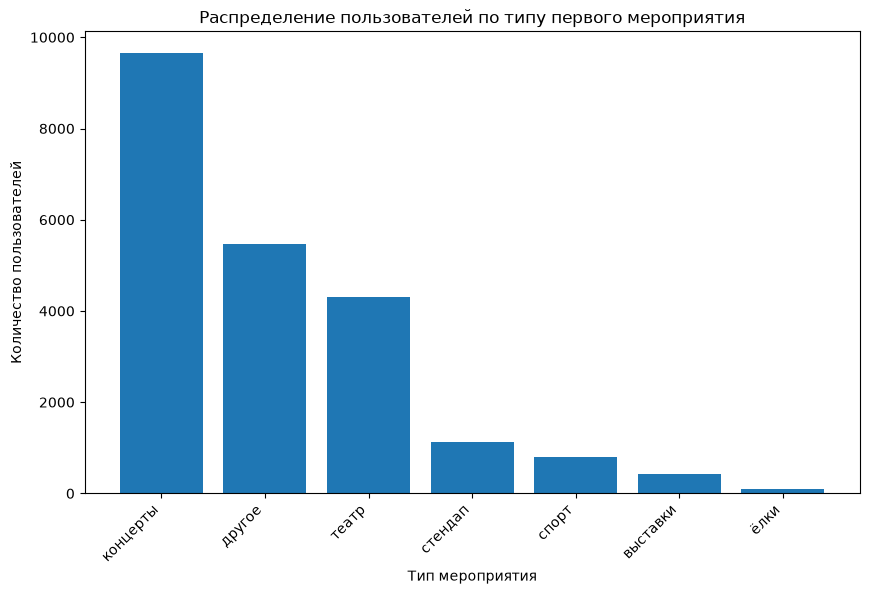

In [80]:
plt.figure(figsize=(10, 6))

plt.bar(
    first_event['event_type_main'],
    first_event['users_count']
)

plt.title('Распределение пользователей по типу первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')

plt.xticks(rotation=45, ha='right')

plt.show()

In [81]:
# Распределение по типу устройства первого заказа
first_device = (user_profile['device_type_canonical'].value_counts().reset_index())

first_device.columns = ['device_type_canonical', 'users_count']

first_device['part'] = (first_device['users_count'] / users_count * 100).round(2)

first_device

,device_type_canonical,users_count,part
0,mobile,18090,82.84
1,desktop,3748,17.16


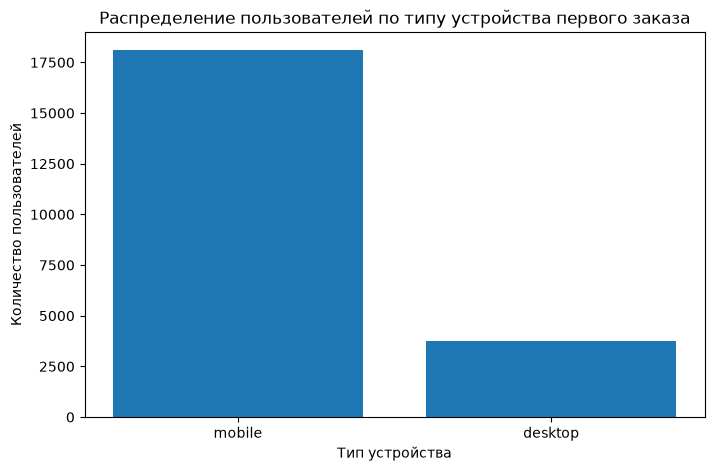

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    first_device['device_type_canonical'],
    first_device['users_count']
)

plt.title('Распределение пользователей по типу устройства первого заказа')
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')

plt.show()

In [83]:
# Распределение по регионам первого заказа
first_region = (user_profile['region_name'].value_counts().reset_index())

first_region.columns = ['region_name', 'users_count']

first_region['part'] = (first_region['users_count'] / users_count * 100).round(2)

first_region

,region_name,users_count,part
0,Каменевский регион,7160,32.79
1,Североярская область,3800,17.40
2,Широковская область,1236,5.66
3,Озернинский край,678,3.10
4,Малиновоярский округ,530,2.43
...,...,...,...
76,Светолесский край,2,0.01
77,Тихогорская область,2,0.01
78,Сосноводолинская область,1,0.00
79,Яснопольский округ,1,0.00


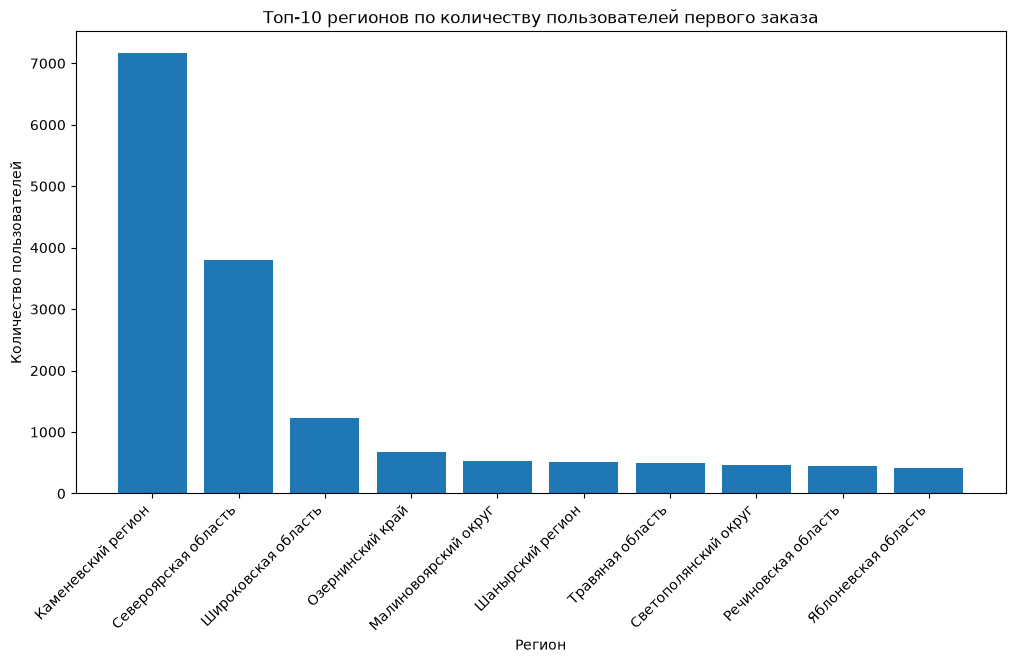

In [84]:
# Так как регионов очень много, то отобразим топ-10
top_regions = first_region.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_regions['region_name'],
    top_regions['users_count']
)

plt.title('Топ-10 регионов по количеству пользователей первого заказа')
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')

plt.xticks(rotation=45, ha='right')

plt.show()

In [85]:
# Распределение по билетным операторам первого билета
first_service = (user_profile['service_name'].value_counts().reset_index())

first_service.columns = ['service_name', 'users_count']

first_service['part'] = (first_service['users_count'] / users_count * 100).round(2)

first_service

,service_name,users_count,part
0,Билеты без проблем,5204,23.83
1,Мой билет,2993,13.71
2,Лови билет!,2851,13.06
3,Билеты в руки,2592,11.87
4,Облачко,2194,10.05
5,Весь в билетах,1305,5.98
6,Лучшие билеты,1186,5.43
7,Прачечная,588,2.69
8,Край билетов,459,2.10
9,Дом культуры,358,1.64


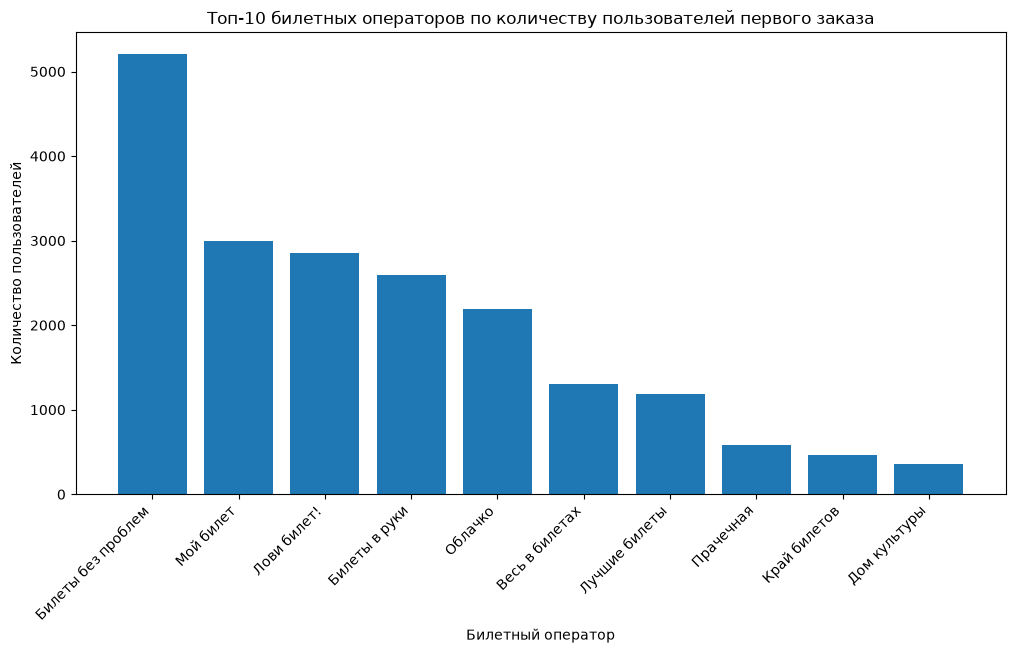

In [86]:
top_services = first_service.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_services['service_name'],
    top_services['users_count']
)

plt.title('Топ-10 билетных операторов по количеству пользователей первого заказа')
plt.xlabel('Билетный оператор')
plt.ylabel('Количество пользователей')

plt.xticks(rotation=45, ha='right')

plt.show()

Распределение пользователей по признакам первого заказа не является равномерным. По всем рассмотренным признакам наблюдаются сегменты, которые имеют доминирующие позиции.

По типу первого мероприятия наиболее крупным сегментом являются пользователи, впервые приобретавшие билеты на концерты - 44.18%, далее следует категория "другое" - 25.03% и "театр" - 19.67%.

По типу устройства наблюдается высокая концентрация пользователей, совершивших первый заказ через мобильное устройство (82.84%), для компьютера всего 17.16%.

По регионам также присутсвуют выраженные сегменты. На Каменевский регион приходится 32.79% пользователей, на Североярскую область - 17.40%. При этом стоит отметить, что общее количество регионов равн0 81.

Распределение по билетным операторам также неравномерно. Наиболее крупным сегментом является "Билеты без проблем" - 23.83%. Далее идут "Мой билет" - 13.71%, "Лови билет!" - 13.06%, "Билеты в руки" - 11.87% и "Облачко" - 10.05%. Общее количество билетных операторов равно 34.

Таким образом, для пользователей существуют выраженные "точки входа". Наиболее заметная концентрации наблюдается по типу устройства: практически все пользователи используют мобильное устройство для первого заказа. Среди типов мероприятий преобладают концерты, а среди регионов - Каменевский. Для билетных операторов можно выделить несколько крупных сегментов.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [87]:
return_rate = user_profile['is_two'].sum() / user_profile['user_id'].nunique()  * 100

print('Доля пользователей с 2 и более заказами:', round(return_rate, 2), '%')

Доля пользователей с 2 и более заказами: 61.7 %


In [88]:
# Доля пользователей вернувшихся по типу мероприятия
return_event = (
    user_profile.groupby('event_type_main').agg(users_count=('user_id', 'count'),returned_users=('is_two', 'sum')
    )
    .reset_index()
)

return_event['return_rate'] = (return_event['returned_users'] / return_event['users_count'] * 100).round(2)

return_event = return_event.sort_values('return_rate', ascending=False)
return_event

,event_type_main,users_count,returned_users,return_rate
0,выставки,417,269,64.51
5,театр,4295,2743,63.86
2,концерты,9647,5995,62.14
4,стендап,1118,684,61.18
1,другое,5465,3281,60.04
3,спорт,801,450,56.18
6,ёлки,95,53,55.79


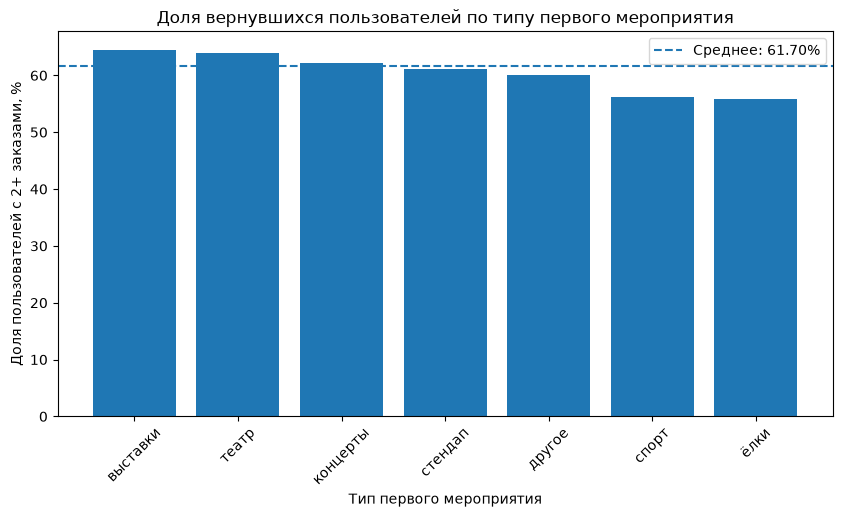

In [89]:
plt.figure(figsize=(10, 5))

plt.bar(
    return_event['event_type_main'],
    return_event['return_rate']
)

plt.axhline(
    return_rate,
    linestyle='--',
    label=f'Среднее: {return_rate:.2f}%'
)

plt.title('Доля вернувшихся пользователей по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [90]:
# Доля возвратов по типу устройства
return_device = (
    user_profile.groupby('device_type_canonical').agg(users_count=('user_id', 'count'), returned_users=('is_two', 'sum'))
    .reset_index()
)

return_device['return_rate'] = (return_device['returned_users'] / return_device['users_count'] * 100).round(2)

return_device = return_device.sort_values('return_rate', ascending=False)
return_device

,device_type_canonical,users_count,returned_users,return_rate
0,desktop,3748,2404,64.14
1,mobile,18090,11071,61.20


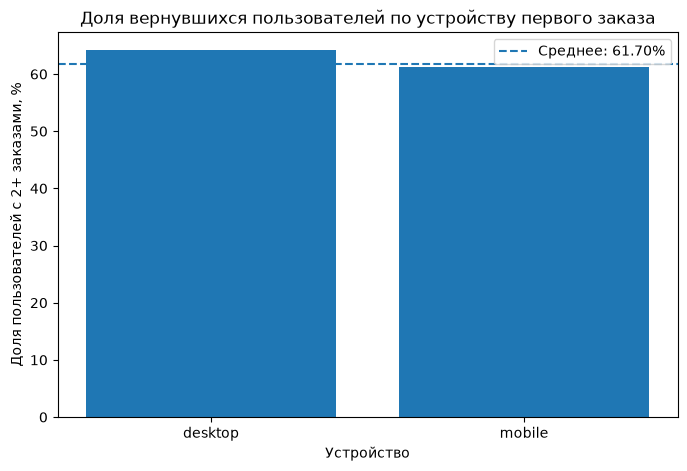

In [91]:
plt.figure(figsize=(8, 5))

plt.bar(
    return_device['device_type_canonical'],
    return_device['return_rate']
)

plt.axhline(
    return_rate,
    linestyle='--',
    label=f'Среднее: {return_rate:.2f}%'
)

plt.title('Доля вернувшихся пользователей по устройству первого заказа')
plt.xlabel('Устройство')
plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.legend()
plt.show()

In [92]:
# Доля возвратов по региону заказа
return_region = (
    user_profile.groupby('region_name').agg(users_count=('user_id', 'count'),returned_users=('is_two', 'sum'))
    .reset_index()
)

return_region['return_rate'] = (return_region['returned_users'] / return_region['users_count'] * 100).round(2)

return_region = return_region.sort_values('return_rate', ascending=False)
return_region.head(25)

,region_name,users_count,returned_users,return_rate
5,Верхозёрский край,1,1,100.00
46,Озернопольская область,29,26,89.66
51,Радужнопольский край,24,19,79.17
36,Лесостепной край,61,44,72.13
12,Горноземский регион,29,20,68.97
11,Горицветская область,255,173,67.84
76,Шанырский регион,505,341,67.52
79,Ягодиновская область,64,43,67.19
2,Берёзовская область,115,77,66.96
71,Тихолесский край,9,6,66.67


In [93]:
top_regions = (return_region.sort_values('users_count', ascending=False).head(10))

top_regions

,region_name,users_count,returned_users,return_rate
23,Каменевский регион,7160,4495,62.78
60,Североярская область,3800,2437,64.13
77,Широковская область,1236,801,64.81
45,Озернинский край,678,376,55.46
41,Малиновоярский округ,530,298,56.23
76,Шанырский регион,505,341,67.52
74,Травяная область,493,305,61.87
57,Светополянский округ,464,307,66.16
52,Речиновская область,446,285,63.90
78,Яблоневская область,416,249,59.86


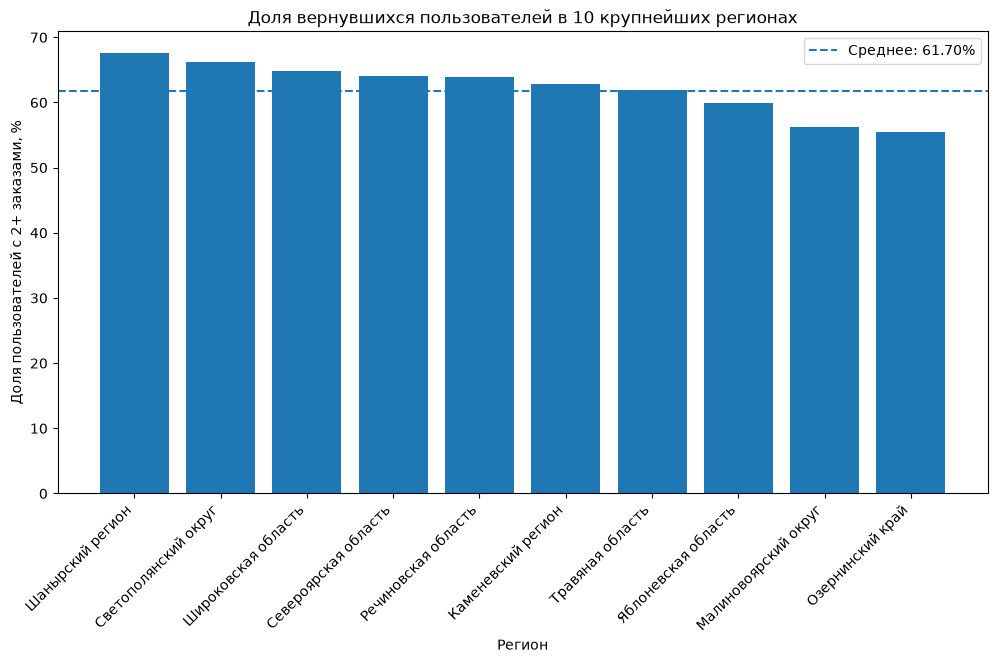

In [94]:
top_regions = top_regions.sort_values('return_rate', ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    top_regions['region_name'],
    top_regions['return_rate']
)

plt.axhline(
    return_rate,
    linestyle='--',
    label=f'Среднее: {return_rate:.2f}%'
)

plt.title('Доля вернувшихся пользователей в 10 крупнейших регионах')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

In [95]:
# Возврат по билетному оператору
return_service = (
    user_profile.groupby('service_name').agg(users_count=('user_id', 'count'),returned_users=('is_two', 'sum'))
    .reset_index()
)

return_service['return_rate'] = (return_service['returned_users'] / return_service['users_count'] * 100).round(2)

return_service


,service_name,users_count,returned_users,return_rate
0,Crazy ticket!,45,31,68.89
1,Show_ticket,163,108,66.26
2,Билет по телефону,6,5,83.33
3,Билеты без проблем,5204,3154,60.61
4,Билеты в руки,2592,1640,63.27
5,Быстробилет,162,96,59.26
6,Быстрый кассир,61,52,85.25
7,Весь в билетах,1305,828,63.45
8,Восьмёрка,86,59,68.60
9,Вперёд!,7,4,57.14


In [96]:
# 10 крупнейших билетных операторов по количеству пользователей
top_services = (return_service.sort_values('users_count', ascending=False).head(10))

top_services

,service_name,users_count,returned_users,return_rate
3,Билеты без проблем,5204,3154,60.61
22,Мой билет,2993,1831,61.18
19,Лови билет!,2851,1753,61.49
4,Билеты в руки,2592,1640,63.27
23,Облачко,2194,1350,61.53
7,Весь в билетах,1305,828,63.45
20,Лучшие билеты,1186,729,61.47
24,Прачечная,588,370,62.93
17,Край билетов,459,301,65.58
12,Дом культуры,358,232,64.80


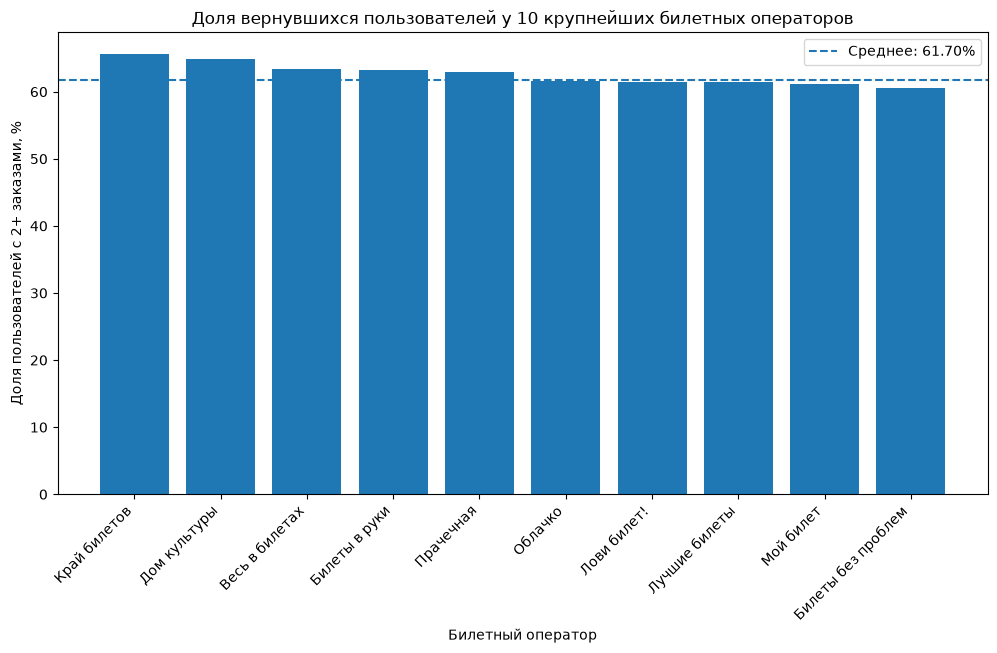

In [97]:
top_services = top_services.sort_values('return_rate', ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    top_services['service_name'],
    top_services['return_rate']
)

plt.axhline(
    return_rate,
    linestyle='--',
    label=f'Среднее: {return_rate:.2f}%'
)

plt.title('Доля вернувшихся пользователей у 10 крупнейших билетных операторов')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

Доля пользователей, совершивших два и более заказа, составляет 61.7%.

При анализе типа первого мероприятия наиболее высокая доля возврата наблюдается среди пользователей, которые купили билеты на выставку - 64.51%. При этом сегмент выставок относительно небольшой - всего 417 пользователей. Более крупные сегменты театра и концертов также имеют долю возвратов выше среднего: 63.86% и 62.14% соответственно.

По устройству первого заказа доля вернувшихся пользователей среди пользователей ПК составляет 64.14%, а среди мобильных устройств - 61.20%. Однако пользователей мобильных устройств в несколько раз больше и разница в процентном отношении невелика.

Среди 10 крупнейших регионов наиболее высокая доля возврата наблюдается в Шанырском регионе - 67.52%, Светлогорском округе - 66.16% и Широковской области - 64.81%. При этом Широковская область и Североярская область представляют собой достаточно крупные сегменты - 1236 и 3800 пользователей соответственно. Поэтому их показатели представляют наибольший интерес. Стоит отметить, что высокие показатели в относительно небольших сегментах способны заметно изменять долю в ту или иную сторону. Поэтому при поиске потенциальных "точек входа" стоит отдавать предпочтение сегментам, которые одновременно имеют высокий уровень возврата и значительное количество пользователей.

Среди 10 крупнейших билетных операторов наибольший процент возврата приходится на "Край билетов" - 65.58%, "Дом культуры" - 64.80%. При этом небольшие сегменты с очень высокой долей возврата не следует считать хорошими данными при анализе. Например показатель 100% для оператора "Зе Бест!" основан всего на одном пользователе.

Таким образом, среди достаточно крупных сегментов выше среднего уровня возврата наблюдаются пользователи, чей первый заказ связан с театром и концертами, пользователи с первым заказом через ПК. Некоторые крупные регионы и билетные операторы также имеют высокие значения уровня возврата. Эти сегменты рекомендуется рассматривать как потенциальные успешные "точки входа", посколько в них доля пользователей с повторным заказом превышает среднее значение по выборке.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1 не подтверждается.** Доля пользователей с повторным заказом среди тех, кто впервые приобрёл билеты на спортивные мероприятия, составляет 56.18%, тогда как среди пользователей, начавших с концертов - 62.14%. Таким образом, в рассматриваемой выборке пользователи, совершившие первую покупку на спортивное мероприятие, возвращаются реже, чем пользователи, начавшие с концертов.

Вторую гипотезу будем оценивать на топ-10 регионах.

**Гипотеза 2 не подтверждается.** Среди крупнейших регионов по количеству пользователей наблюдаются как значения доли повторных заказов выше среднего уровня по выборке (61.70%), так и значения ниже него. Например, в Каменевском регионе, который является крупнейшим сегментом (7160 пользователей), доля повторных заказов составляет 62.78%, а во втором по крупноте регионе (Североярской области) при количестве пользователей, равном 3800, наблюдается более высокий процент - 64.13. Таким образом, увеличение количества пользователей в регионе не сопровождается однозначным увеличением доли повторных заказов. 

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [98]:
one_order = user_profile[user_profile['is_two'] == 0]['avg_revenue_rub']

more_one_order = user_profile[user_profile['is_two'] == 1]['avg_revenue_rub']

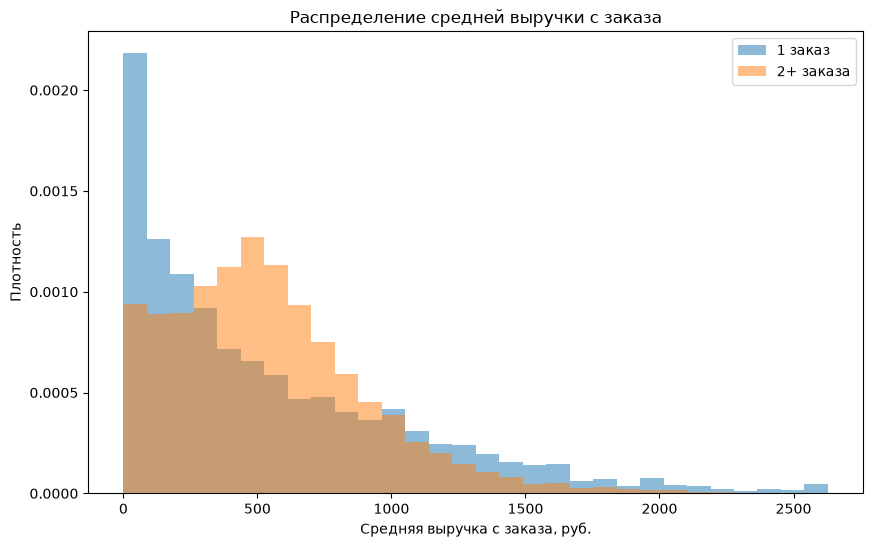

In [99]:
# Визуализируемя
plt.figure(figsize=(10, 6))

plt.hist(
    one_order,
    bins=30,
    density=True,
    alpha=0.5,
    label='1 заказ'
)

plt.hist(
    more_one_order,
    bins=30,
    density=True,
    alpha=0.5,
    label='2+ заказа'
)

plt.title('Распределение средней выручки с заказа')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()

plt.show()

In [100]:
print('1 заказ:')
print(one_order.quantile([0.25, 0.5, 0.75]))

print('\n2+ заказа:')
print(more_one_order.quantile([0.25, 0.5, 0.75]))

1 заказ:
0.25    133.055000
0.50    378.869995
0.75    830.975006
Name: avg_revenue_rub, dtype: float64

2+ заказа:
0.25    274.977997
0.50    498.085022
0.75    739.813080
Name: avg_revenue_rub, dtype: float64


Как видно из результатов, распределение средней выручки с заказа у пользователей с одним и двумя и более заказами различаются. В целом у вернувшихся пользователей средняя выручка с заказа смещена в сторону более высоких значений в нижней и центральной части распределения, тогда как пользователи с одним заказом характеризуются более широким разбросом значений.

У пользователей с одним заказом 50% центральных значений находятся в диапозоне от 133 до 831 руб, медиана при этом составляет 379 руб. У вернувшихся пользователей центральные 50% значений находятся в диапозоне от 275 до 740 руб, а медиана заметно выше и составляет 498 руб. 

Таким образом, пользователи с повторными заказами чаще концентрируются в диапозоне 275-740 руб. за заказ и имеют более высокую среднюю выручку. Пользователи с одним заказом, напротив, имеют больший разброс: среди них встречаются больше как пользователи с низкой средней выручкой, так и пользователи с высокой средней выручкой.

Одной из причин такого распределения может быть разный характер покупок. Низкие значения средней выручки у пользователей с одним заказом могут быть связаны с возвратами. При этом высокие значения объясняются разовыми крупными покупками для группы. У пользователей с повторными заказами распределение более концентрированное, говорящее о стабильности характера покупок.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [101]:
# Создадим переменные по количествам заказов
orders_2_4 = user_profile[user_profile['total_orders'].between(2, 4)]['avg_revenue_rub']
print ('Пользователей с 2-4 заказами:', len(orders_2_4))

orders_5_more = user_profile[user_profile['total_orders'] >= 5]['avg_revenue_rub']
print ('Пользователей с 5 и более заказами:', len(orders_5_more))

Пользователей с 2-4 заказами: 7145
Пользователей с 5 и более заказами: 6330


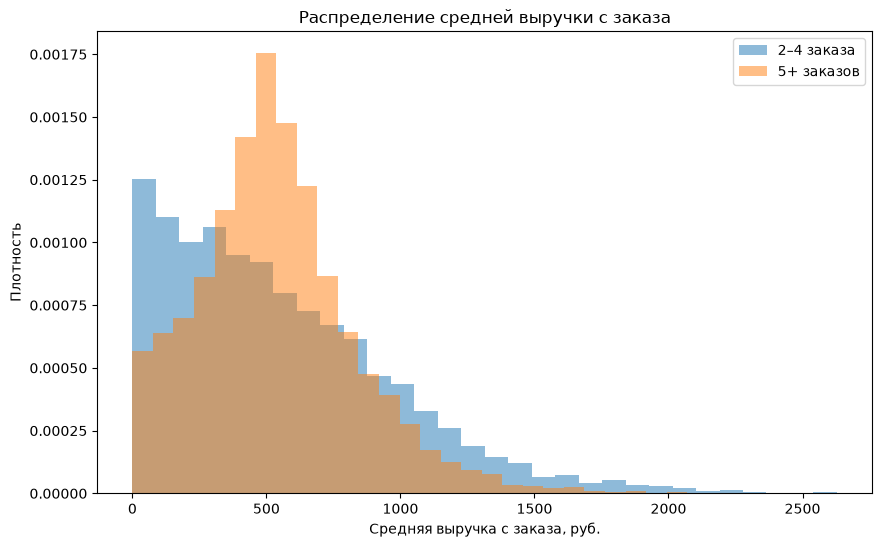

In [102]:
plt.figure(figsize=(10, 6))

plt.hist(
    orders_2_4,
    bins=30,
    density=True,
    alpha=0.5,
    label='2–4 заказа'
)

plt.hist(
    orders_5_more,
    bins=30,
    density=True,
    alpha=0.5,
    label='5+ заказов'
)

plt.title('Распределение средней выручки с заказа')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.legend()

plt.show()

In [103]:
print('2–4 заказа:')
print(orders_2_4.quantile([0.25, 0.5, 0.75]))

print('\n5+ заказов:')
print(orders_5_more.quantile([0.25, 0.5, 0.75]))

2–4 заказа:
0.25    219.500000
0.50    472.470001
0.75    798.830017
Name: avg_revenue_rub, dtype: float64

5+ заказов:
0.25    338.358315
0.50    513.958527
0.75    690.451736
Name: avg_revenue_rub, dtype: float64


Распределения средней выручки для пользователей с 2-4 заказами и для тех, кто совершил более 4 заказов, имеют различия. У пользователей с 5 и более заказами медианная средняя выручка составляет 513.96 руб, что немного выше того же показателя для пользователей с 2-4 заказами. Значение 25-го перцентиля также выше для пользователей с 5 и более заказами: 338.36 руб. против 219.50.

Однако 75-й перцентиль у пользователей с 2-4 заказами выше: 798.83 руб против 690.45 руб. Таким образом, нельзя говорить о прямой зависимости между количеством заказов и средней выручкой заказа.

В целом пользователи с 5 и более заказами имеют немного большие значения средней выручки в центральной части распеределения. Хотя различия по средней выручке между группами присутсвуют, но они не являются выраженными на всем диапозоне.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [104]:
user_profile['avg_tickets_count'].describe()

count    21838.000000
mean         2.744063
std          0.913068
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max         11.000000
Name: avg_tickets_count, dtype: float64

Большинство пользователей находится в диапозоне 2-3 билета за заказ.

In [105]:
segment_1_2 = user_profile[(user_profile['avg_tickets_count'] >= 1) &(user_profile['avg_tickets_count'] < 2)]

segment_2_3 = user_profile[(user_profile['avg_tickets_count'] >= 2) &(user_profile['avg_tickets_count'] < 3)]

segment_3_5 = user_profile[(user_profile['avg_tickets_count'] >= 3) &(user_profile['avg_tickets_count'] < 5)]

segment_5_more = user_profile[user_profile['avg_tickets_count'] >= 5]

In [106]:
print('1–2 билета:', len(segment_1_2))
print('2–3 билета:', len(segment_2_3))
print('3–5 билетов:', len(segment_3_5))
print('5+ билетов:', len(segment_5_more))

1–2 билета: 2410
2–3 билета: 9694
3–5 билетов: 9073
5+ билетов: 661


In [107]:
# Доля возвратов при покупке n-го числа билетов
print('1–2 билета:', round(segment_1_2['is_two'].mean() * 100, 2), '%')
print('2–3 билета:', round(segment_2_3['is_two'].mean() * 100, 2), '%')
print('3–5 билетов:', round(segment_3_5['is_two'].mean() * 100, 2), '%')
print('5+ билетов:', round(segment_5_more['is_two'].mean() * 100, 2), '%')

1–2 билета: 51.24 %
2–3 билета: 74.13 %
3–5 билетов: 54.34 %
5+ билетов: 18.76 %


Распределение пользователей по среднему количеству билетов в заказе является неравномерным. Наиболее крупными являются сегменты от 2 до 3 билетов - 9694 пользователя и от 3 до 5 билетов - 9073 пользователя. При этом сегменты 1-2 билета и 5+ билетов значительно меньше - 2410 и 661 пользователь соответственно.

Доля поользователей, вернувшихся повторно, заметно различается между сегментами. В группе от 1 до 2 билетов она составляет 51.24%, в группе 2-3 билета целых 74.13%, в группе от 3 до 5 билетов - 54.34%, а среди пользователей с 5 и более билетами всего 18.76%. Для сравнения, доля пользователей с повторными заказами по всей выборке составляет 61.70%. 

Таким образом, прямой зависимости между средним количеством билетов в заказе и вероятностью возврата клиента не наблюдается. Наиболее высокая доля повторных заказов приходится не на пользователей с самым большим количеством билетов, а на сегмент 2-3 билета. Полученные результаты говорят о том, что пользователи с разным средним количеством билетов за покупку показывают разную долю повторных покупок.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [108]:
# Выделим день недели
user_profile['first_order_weekday'] = user_profile['first_order_dt'].dt.day_name()

In [109]:
# Переименуем в русские названия
days = {
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
}

user_profile['first_order_weekday'] = (user_profile['first_order_dt'].dt.day_name().map(days))

In [110]:
user_profile['first_order_weekday'].value_counts()

first_order_weekday
Суббота        3456
Пятница        3258
Вторник        3188
Четверг        3119
Среда          3076
Понедельник    2931
Воскресенье    2810
Name: count, dtype: int64

In [111]:
weekday_return = (
    user_profile.groupby('first_order_weekday').agg(
        users_count=('user_id', 'count'), return_rate=('is_two', 'mean'))
    .reset_index()
)

weekday_return['return_rate'] = weekday_return['return_rate'] * 100

weekday_return

,first_order_weekday,users_count,return_rate
0,Воскресенье,2810,60.533808
1,Вторник,3188,62.045169
2,Понедельник,2931,63.152508
3,Пятница,3258,59.791283
4,Среда,3076,62.451235
5,Суббота,3456,64.207176
6,Четверг,3119,59.538314


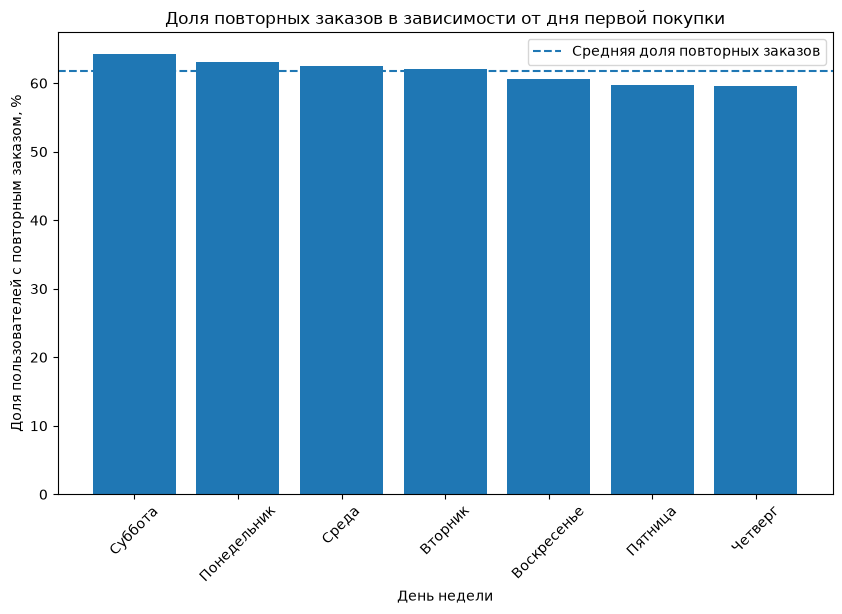

In [112]:
weekday_return = weekday_return.sort_values('return_rate', ascending = False)

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_return['first_order_weekday'],
    weekday_return['return_rate']
)

plt.axhline(
    user_profile['is_two'].mean() * 100,
    linestyle='--',
    label='Средняя доля повторных заказов'
)

plt.title('Доля повторных заказов в зависимости от дня первой покупки')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей с повторным заказом, %')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Распределение пользователей по дню недели первого заказа является относительно равномерным. Количество пользователей в зависимости от дня первой покупки находится в диапозоне от 2810 до 3459 человек. Наибольшее колмчество пользователей приходится на субботу - 3459, а наименьшее на воскресенье - 2810.

Доля пользователей, совершивших повторный заказ, также различается по дням неделям. Наибольшая доля возврата наблюдается у пользователей, совершивших первую покупку в субботу (64.24%). Наименьшая доля наблюдается для четверга - 59.52% и пятницы - 59.86%.

При этом стоит отметить общий уровень повторных заказов среди пользователей, который составляет 61.71%. Относительно этого параметра данные по дням неделям имеют небольшие различия (менее 3%).

Таким образом, выраженного влияния дня недели первой покупки на вероятность воззврата пользователя не неблюдается. Некоторые различия между днями присутсвуют, однако ни один день не демонстрирует сильного отклонения от общего уровня.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [113]:
orders_between_24 = user_profile[user_profile['total_orders'].between(2, 4)]

orders_5_plus = user_profile[user_profile['total_orders'] >= 5]

print('Средний интервал для 2–4 заказов:',round(orders_between_24['avg_days_between_orders'].mean(), 2), 'дней')

print('Средний интервал для 5+ заказов:', round(orders_5_plus['avg_days_between_orders'].mean(), 2), 'дней')

Средний интервал для 2–4 заказов: 21.31 дней
Средний интервал для 5+ заказов: 9.59 дней


Средние значения интервала мы определили, но проверим нет ли каких-то аномальных значений, искажающие данные. Построим для этого гистограммы для двух сегментов. Для лучшей наглядности покажем значения на одном и том же промежутке.

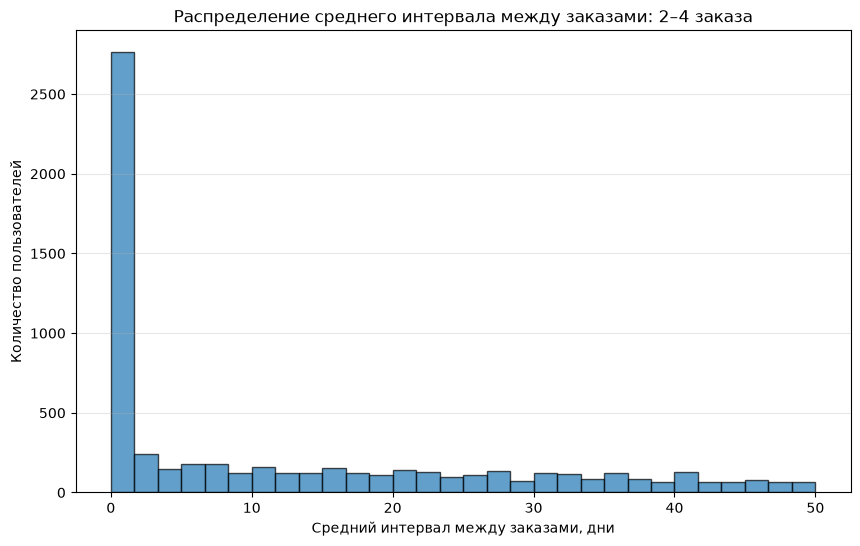

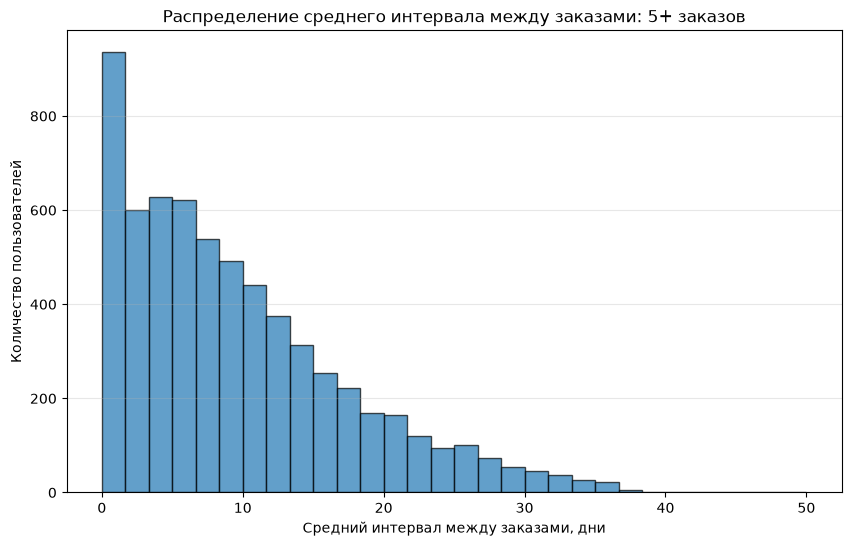

In [114]:
plt.figure(figsize=(10, 6))

plt.hist(
    orders_between_24['avg_days_between_orders'],
    bins=30,
    range=(0, 50),
    alpha=0.7,
    edgecolor='black'
)

plt.xlabel('Средний интервал между заказами, дни')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего интервала между заказами: 2–4 заказа')
plt.grid(axis='y', alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))

plt.hist(
    orders_5_plus['avg_days_between_orders'],
    bins=30,
    range=(0, 50),
    alpha=0.7,
    edgecolor='black'
)

plt.xlabel('Средний интервал между заказами, дни')
plt.ylabel('Количество пользователей')
plt.title('Распределение среднего интервала между заказами: 5+ заказов')
plt.grid(axis='y', alpha=0.3)
plt.show()

Как видно, в данных присутсвуют сильные забросы данных на низких значениях интервала между заказами. Поэтому следует более детально оценить эти данные.

In [115]:
for name, group in [('2–4 заказа', orders_between_24), ('5+ заказов', orders_5_plus)]:
    print(name)
    print('Среднее:', round(group['avg_days_between_orders'].mean(), 2))
    print('Медиана:', round(group['avg_days_between_orders'].median(), 2))
    print('Q1:', round(group['avg_days_between_orders'].quantile(0.25), 2))
    print('Q3:', round(group['avg_days_between_orders'].quantile(0.75), 2))
    print('Минимум:', round(group['avg_days_between_orders'].min(), 2))
    print('Максимум:', round(group['avg_days_between_orders'].max(), 2))
    print()

2–4 заказа
Среднее: 21.31
Медиана: 9.0
Q1: 0.0
Q3: 34.0
Минимум: 0.0
Максимум: 148.0

5+ заказов
Среднее: 9.59
Медиана: 7.79
Q1: 3.43
Q3: 13.8
Минимум: 0.0
Максимум: 37.5



Для пользователей с 2-4 заказами значение среднего интервала сильно завышено. Основная причина - длинный диапозон значений среди всех пользователей.

При оценке сегментов по медиане, результаты получаются совсем другие: для половины пользователей с 2-4 заказами средний интервал не превышает 9 дней, тогда как для пользователей с 5 и более заказами 7.79 дней.

Средний интервал между заказами у пользователей с 2-4 заказами составляет 21.33 дня, а у пользователей с 5 и более заказами - 9.58 дня. На первый взгляд это указывает на значительно более высокую частоту покупок у наиболее активных пользователей.

Однако распределение интервалов показывает, что среднее значение для группы с 2-4 заказами значительно завышено из-за длинного диапозона значений. Медианный интервал составляет всего 9 дней, а 75% пользователей имеют средний интервал не более 34 дней. Максимальное значение при этом равно 148 дням, которое соответствует мало активному пользователю.

В группе 5+ заказов среднее и медиана ближе друг к другу: 9,59 и 7,79 соответственно. Кроме того 75% пользователей имеют интервал не выше 13.8 дней, а максимальное значение 37.5 дня. Это свидетельствует о том, что данный сегмент имеет предрасположенность к более стабильной частоте покупок.

Таким образом, при сильном отличии среднего значения у сегментов, их медианные значения находятся близко друг к другу. Основными различиями являются разброс значений и его степень: пользователи с 2-4 заказами сильнее различаются по частоте повторных покупок, тогда как пользователи с 5+ заказами имеют более стабильную характеристику с короткими интервалами.

В целом результаты указывают на связь между регулярностью покупок и количеством повторных заказов, однако прямой зависимости между ростом количества заказов и уменьшением интервала не наблюдается.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [116]:
# Составляем матрицу коррелляции 
correlation_matrix = user_profile[
    [
        'total_orders',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between_orders',
        'device_type_canonical',
        'region_name',
        'service_name',
        'event_type_main'
    ]
].phik_matrix()

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between_orders']


In [117]:
correlation_matrix['total_orders'].sort_values(ascending=False)

total_orders               1.000000
region_name                0.128413
service_name               0.101877
avg_revenue_rub            0.000000
avg_days_between_orders    0.000000
avg_tickets_count          0.000000
device_type_canonical      0.000000
event_type_main            0.000000
Name: total_orders, dtype: float64

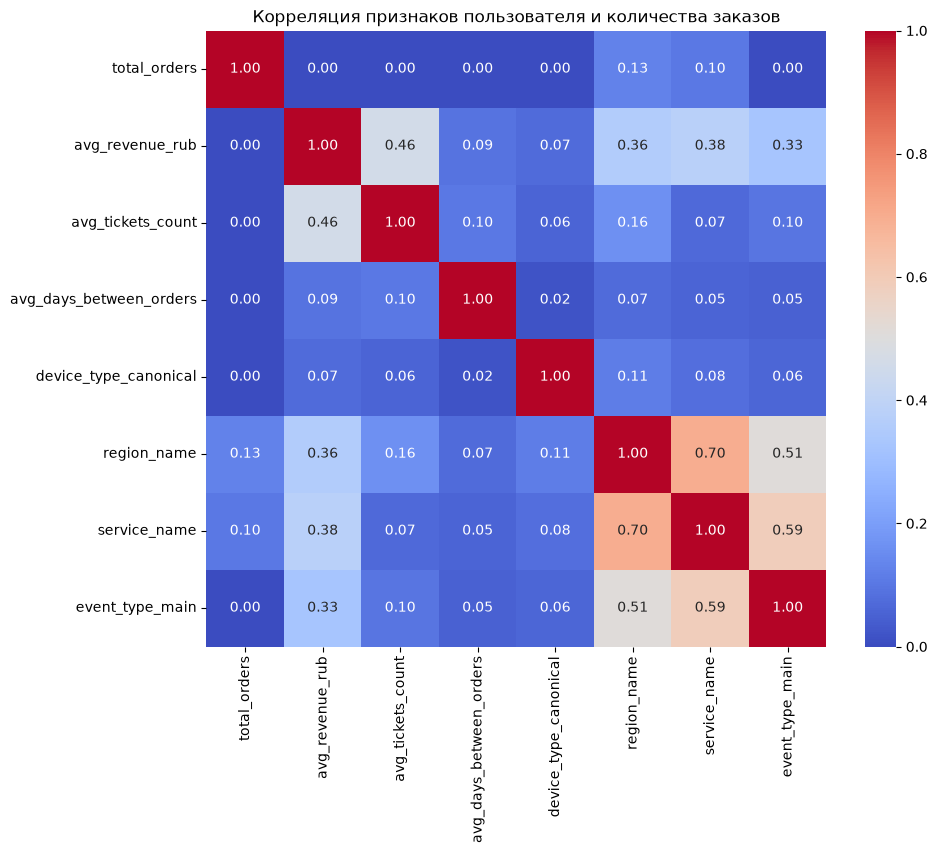

In [118]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Корреляция признаков пользователя и количества заказов')
plt.show()

Большинство значений связи с total_orders равны 0. Поэтому проведем сегментацию и также выявим связь.

In [119]:
user_profile['orders_segment'] = '1 заказ'

user_profile.loc[user_profile['total_orders'].between(2, 4), 'orders_segment'] = '2–4 заказа'

user_profile.loc[user_profile['total_orders'] >= 5, 'orders_segment'] = '5+ заказов'

In [120]:
correlation_matrix_segment = user_profile[
    [
        'orders_segment',
        'avg_revenue_rub',
        'avg_tickets_count',
        'avg_days_between_orders',
        'device_type_canonical',
        'region_name',
        'service_name',
        'event_type_main'
    ]
].phik_matrix()

interval columns not set, guessing: ['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between_orders']


In [121]:
correlation_matrix_segment['orders_segment'].sort_values(ascending=False)

orders_segment             1.000000
avg_days_between_orders    0.393224
avg_tickets_count          0.390381
avg_revenue_rub            0.333679
region_name                0.125836
service_name               0.086598
event_type_main            0.041869
device_type_canonical      0.016474
Name: orders_segment, dtype: float64

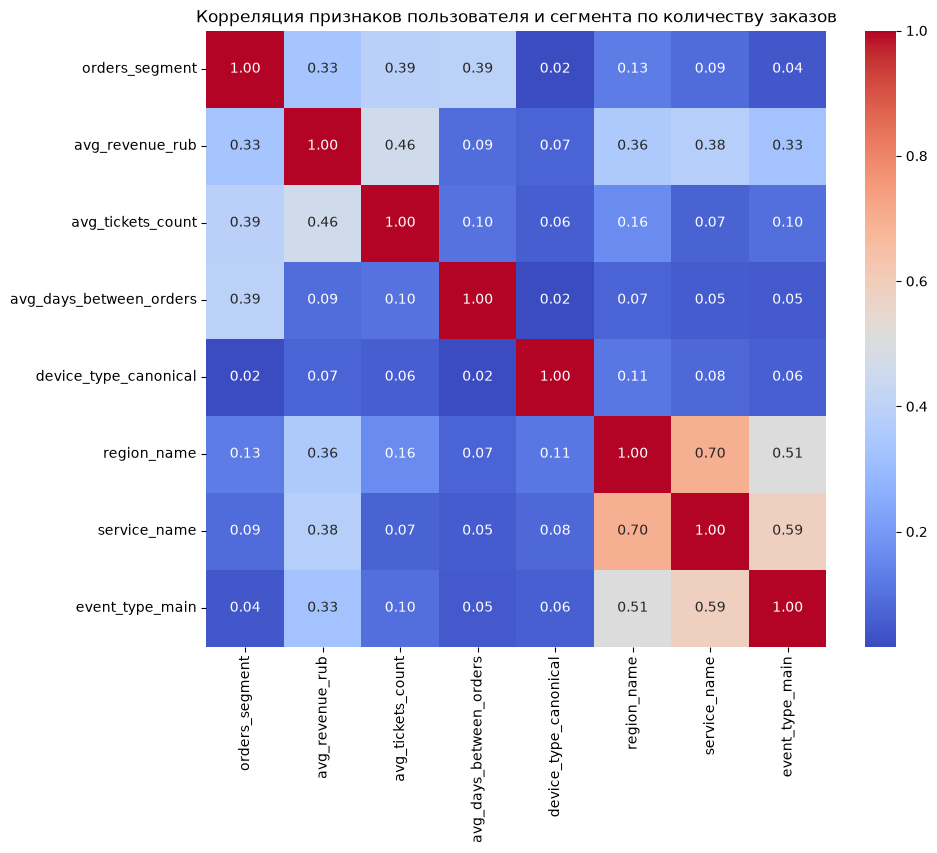

In [122]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix_segment,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Корреляция признаков пользователя и сегмента по количеству заказов')
plt.show()

При первоначальном расчёте большинство коэффициентов phi_k с total_orders оказались близки к нулю. Наиболее заметная связь наблюдалась с регионом — 0.128 и сервисом — 0.102. Это связано с сильной неравномерностью распределения количества заказов, поэтому далее пользователи были разделены на три сегмента: 1 заказ, 2–4 заказа и 5 и более заказов.

После сегментации наиболее сильная связь наблюдается со средним интервалом между заказами — 0.393, средним количеством билетов — 0.390 и средней выручкой с заказа — 0.333. Связь с регионом составляет 0.126, с сервисом — 0.086.

Таким образом, с количеством заказов сильнее всего связаны признаки, характеризующие следующие признаки покупателя: регулярность совершения заказов, количество приобретаемых билетов и средняя выручка с заказа.

При этом характеристики, связанные с регионом первого заказа и выбранным сервисом, имеют значительно более слабую связь с количеством заказов. Следовательно, для анализа повторных покупок поведение пользователей во времени и особенности их покупок (средняя выручка и количество приобретаемых билетов) оказываются более информативными.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Общий вывод.**

В анализе использовались данные о 287 6365 заказах 21 838 пользователей Яндекс Афиши за период с июня по октябрь 2024 года. В выборку вошли пользователи мобильных и desktop-устройств, а заказы на фильмы были исключены. В ходе предобработки значения выручки в тенге были переведены в рубли с использованием дневного курса. Также были проверены пропуски, типы данных и категориальные признаки. Для показателя `revenue_rub` были удалены значения выше 99-го перцентиля — всего 2 825 строк, менее 1% выборки, а также 381 строка с отрицательными значениями. Это позволило снизить влияние аномально крупных значений на результаты анализа.

61,7% пользователей совершили два и более заказа, а 29,0% — пять и более. Медианное количество заказов составляет 2. Среди пользователей с повторными покупками средний интервал между заказами составляет 15,8 дня. При этом у пользователей с 2–4 заказами средний интервал равен 21,33 дня, а у пользователей с 5 и более заказами — 9,59 дня. Дополнительный анализ показал, что среднее значение для группы 2-4 заказа существенно высокое из-за длинного диапозона значений. Медиана составляет всего 9 дней, а максимальный интервал 148 дней. Поэтому для оценки регулярности покупок важно учитывать медиану и тот факт, что 75% значений для сегмента 2-4 заказа располагаются до значения 34 дня.

Анализ первого заказа показал, что наиболее крупным сегментом являются пользователи, впервые купившие билеты на концерты — 44,18%. Большинство пользователей совершили первый заказ с мобильного устройства — 82,84%. Доля повторных заказов среди пользователей первого заказа на концерты составила 62,14%, на театр — 63,86%, а на выставки — 64,51%. Среди desktop-пользователей доля возврата составила 64,14%, среди mobile — 61,20%. Таким образом, театр, концерты и использование desktop-устройств можно рассматривать как потенциально более успешные точки входа, хотя различия между сегментами не позволяют говорить о причинном влиянии.

Прямой зависимости между средней выручкой с заказа и повторными покупками также не обнаружено. Медианная средняя выручка у пользователей с одним заказом составляет 378,87 руб., а у пользователей с двумя и более заказами — 498,09 руб. При сравнении пользователей с 2–4 и 5+ заказами медианная выручка составляет 472,47 и 513,96 руб. соответственно. Среднее количество билетов в заказе также не показывает заметной зависимости с возвратом: наибольшая доля повторных заказов наблюдается у пользователей со средним количеством 2–3 билета — 74,13%, тогда как у пользователей с 5 и более билетами она составляет 18,76%.

День недели первой покупки не оказывает выраженного влияния на возврат: разница между максимальной и минимальной долей повторных заказов составляет около 4,7 процентного пункта. При этом среди уже вернувшихся пользователей более короткие интервалы между покупками характерны для наиболее активных клиентов.

Корреляционный анализ после сегментации пользователей по количеству заказов показал наиболее заметную связь со средним интервалом между заказами (`phi_k` = 0,395), средним количеством билетов (`phi_k` = 0,390) и средней выручкой с заказа (`phi_k` = 0,335). Связь с регионом составила 0,126, с сервисом — 0,085. Эти результаты характеризуют статистическую связь и не означают наличие причинно-следственной зависимости.

**Рекомендации.**
1. Следует направить внимание на пользователей с 2-4 заказами. В ходе анализа было выявлено, что пользователи, совершивших 2-4 заказа, имеет средний интервал между покупками около 21 дня при максимальном значение 148 дней. Для таких пользователей рекомендуется запускать ограниченные по времени персональные предложения и рекомендации, ориентируясь на их интересы и возможные отзывы на мероприятия, проявленные в предыдущих заказах. Основная цель - сократить интервалы между заказами и заинтересовать пользователя покупками билетов на другие мероприятия. Важно отметить, что по статистике пользователи, совершившие 5 и более заказов чаще возвращаются и средний интервал составляет чуть более 9 дней.

2. Использовать категорию первого заказа для подборки мероприятий второго и последующих заказов. Первый заказ может свидетельствовать о том, что пользователь остался доволен первой покупкой, поэтому он вернулся снова. На основании этого суждения, можно создать подборки популярных мероприятий в уже интересующих категориях. Однако анализ данных показал достаточно широкий диапозон значений интервала между покупками, поэтому не стоит воспринимать длительный интервал, как потерю интереса.

3. Корреляционный анализ показал наиболее заметную связь с количеством заказов у среднего интервала между покупками, среднего количества билетов и чуит менее заметную со средней выручкой. Таким образом, рекомендуется считать перспективными пользователями тех, кто совершает регулярные и относительно крупные заказы (примерно от 2 до 5 билетов). Например, пользователь с относительно небольшой средней выручкой с заказа, но регулярными покупками может представлять наибольшую ценность, чем покупатель с очень редкими, но крупными покупками.

4. Подавляющее большинство заказов совершено с мобильных устройств, при этом процент возврата по сравнению с desktop-ными устройствами отличается незначительно. Поэтому рекомендуется чаще использовать push-уведомления или другие возможные способы информирования для мобильных устройств о персональных предложениях и новых мероприятиях. 

5. Для проверки эффективности рекомендаций целесообразно провести A/B-тестирование. Основными группами для эксперимента стоит выбрать пользователей с 2-5 заказами и пользователей, у которых достаточно высокий интервал между покупками (или увеличивающийся интервал). В качестве метрик следует использовать - долю пользователей, совершивших повторный заказ в заднный период, время между покупками и среднее количество заказов. Это позволит оценить, что удерживает людей и какие у них интересы.